# Task 1: Exploratory Data Analysis and Data Preprocessing

This notebook performs the Exploratory Data Analysis (EDA) on the filtered Consumer Financial Protection Bureau (CFPB) complaint dataset. 

**Objectives:**
- Load the processed dataset.
- Analyze the distribution of complaints across products.
- Analyze the length of consumer complaint narratives.
- Visualize the findings.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_theme(style="whitegrid")

## 1. Load Data
Loading the filtered dataset created by `src/data_preprocessing.py`.

In [2]:
PROCESSED_DATA_PATH = '../data/processed/filtered_complaints.csv'

if os.path.exists(PROCESSED_DATA_PATH):
    df = pd.read_csv(PROCESSED_DATA_PATH)
    print(f"Data loaded successfully. Shape: {df.shape}")
else:
    print(f"File not found: {PROCESSED_DATA_PATH}. Please run src/data_preprocessing.py first.")

Data loaded successfully. Shape: (66708, 19)


In [3]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,cleaned_narrative
0,2025-06-13,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78230,Servicemember,Consent provided,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN,14069121,a xxxx xxxx card was opened under my name by a...
1,2025-06-12,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,"Dear CFPB, I have a secured credit card with c...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11220,NaN,Consent provided,Web,2025-06-13,Closed with monetary relief,Yes,NaN,14047085,"dear cfpb, i have a secured credit card with c..."
2,2025-06-12,Credit card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,I have a Citi rewards cards. The credit balanc...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",IL,60067,NaN,Consent provided,Web,2025-06-12,Closed with explanation,Yes,NaN,14040217,i have a citi rewards cards. the credit balanc...
3,2025-06-09,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,b'I am writing to dispute the following charge...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78413,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13968411,b'i am writing to dispute the following charge...
4,2025-06-09,Credit card,General-purpose credit card or charge card,Problem when making payments,Problem during payment process,"Although the account had been deemed closed, I...",Company believes it acted appropriately as aut...,Atlanticus Services Corporation,NY,11212,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13965746,"although the account had been deemed closed, i..."


## 2. Distribution of Complaints by Product
We count the number of complaints for each of the target products.

/tmp/ipykernel_8259/2900130741.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Product', data=df, order=df['Product'].value_counts().index, palette='viridis')


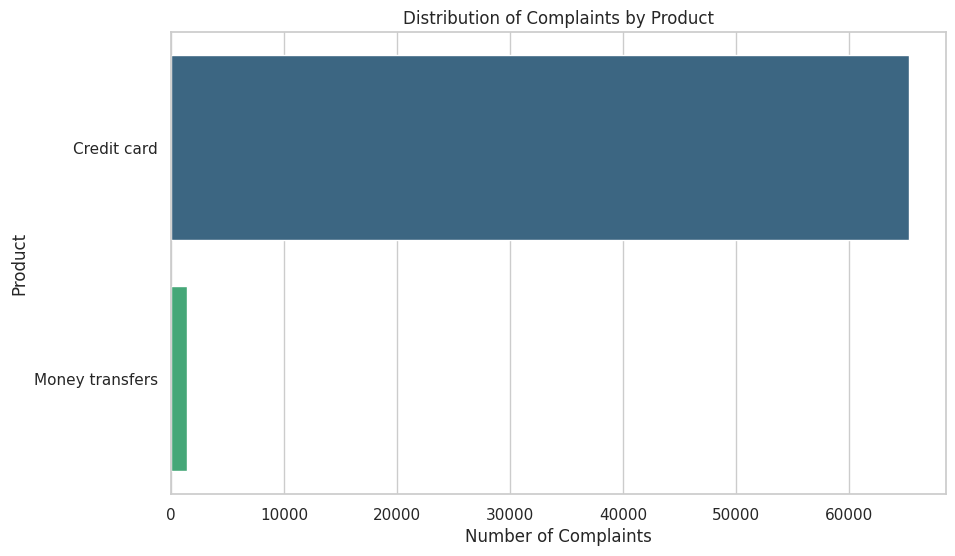

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Product', data=df, order=df['Product'].value_counts().index, palette='viridis')
plt.title('Distribution of Complaints by Product')
plt.xlabel('Number of Complaints')
plt.ylabel('Product')
plt.show()

## 3. Analysis of Narrative Length
We calculate the number of words in each complaint narrative.

In [5]:
# Calculate word count
df['narrative_length'] = df['cleaned_narrative'].astype(str).apply(lambda x: len(x.split()))

# Display statistics
df['narrative_length'].describe()

count    66708.000000
mean       203.466496
std        221.012658
min          2.000000
25%         69.000000
50%        146.000000
75%        265.000000
max       6469.000000
Name: narrative_length, dtype: float64

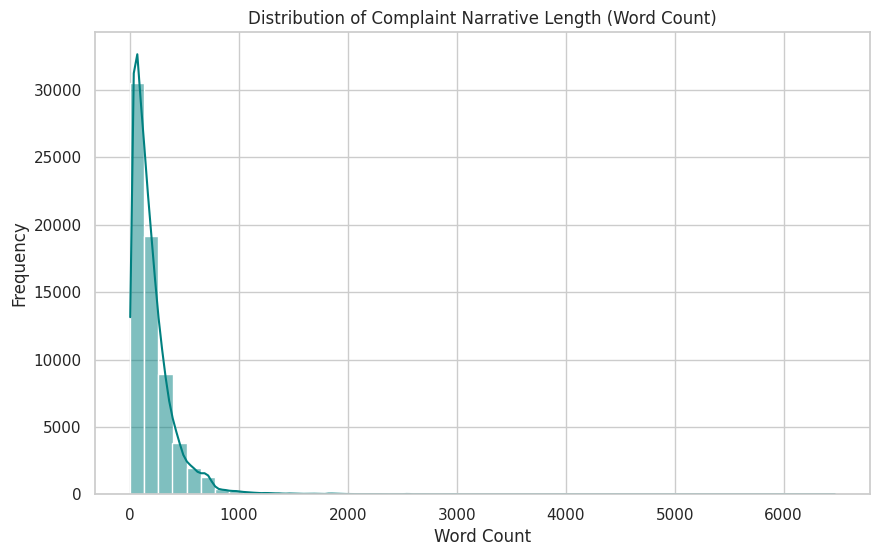

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['narrative_length'], bins=50, kde=True, color='teal')
plt.title('Distribution of Complaint Narrative Length (Word Count)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

## 4. Key Findings
- The distribution plot shows which products have the highest volume of complaints.
- The histogram of narrative lengths highlights the variability in customer detail.